In [322]:
import numpy as np
import pandas as pd
pd.plotting.register_matplotlib_converters()
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from scipy import stats

In [323]:
data = pd.read_csv('/kaggle/input/datasets/shivamb/netflix-shows/netflix_titles.csv')

In [324]:
data.shape

(8807, 12)

In [325]:
data.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [326]:
#DataCleaning
missing_data = data.isnull().sum()
data.date_added = data.date_added.str.strip()
data.duration = data.duration.str.strip()
data.type = data.type.str.strip()



In [327]:
data.dropna(subset=['rating','duration','date_added'], inplace=True)

In [328]:
#Parsing Dates
#Example Date: September 25, 2021

data.date_added = pd.to_datetime(data.date_added, format = '%B %d, %Y')

In [329]:
data['year'] = data.date_added.dt.year
data['month'] = data.date_added.dt.month

In [330]:
data['movie_duration'] = np.where(data.type == 'Movie', data.duration, np.nan)
data['tvshow_duration'] = np.where(data.type == 'TV Show', data.duration, np.nan)



In [331]:
data.sort_values(by=['year','month'], inplace=True)

In [332]:
data.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year,month,movie_duration,tvshow_duration
5957,s5958,Movie,To and From New York,Sorin Dan Mihalcescu,"Barbara King, Shaana Diya, John Krisiukenas, Y...",United States,2008-01-01,2006,TV-MA,81 min,"Dramas, Independent Movies, Thrillers","While covering a story in New York City, a Sea...",2008,1,81 min,NaN
6611,s6612,TV Show,Dinner for Five,NaN,NaN,United States,2008-02-04,2007,TV-MA,1 Season,Stand-Up Comedy & Talk Shows,"In each episode, four celebrities join host Jo...",2008,2,NaN,1 Season
5956,s5957,Movie,Just Another Love Story,Ole Bornedal,"Anders W. Berthelsen, Rebecka Hemse, Nikolaj L...",Denmark,2009-05-05,2007,TV-MA,104 min,"Dramas, International Movies",When he causes a car accident that leaves a yo...,2009,5,104 min,NaN
5955,s5956,Movie,Splatter,Joe Dante,"Corey Feldman, Tony Todd, Tara Leigh, Erin Way...",United States,2009-11-18,2009,TV-MA,29 min,Horror Movies,"After committing suicide, a washed-up rocker r...",2009,11,29 min,NaN
7370,s7371,Movie,Mad Ron's Prevues from Hell,Jim Monaco,"Nick Pawlow, Jordu Schell, Jay Kushwara, Micha...",United States,2010-11-01,1987,NR,84 min,"Cult Movies, Horror Movies","This collection cherry-picks trailers, forgott...",2010,11,84 min,NaN


In [333]:
data.groupby('country').show_id.count().sort_values(ascending=False)
#The United States has dominated the platform.


country
United States          2809
India                   972
United Kingdom          418
Japan                   243
South Korea             199
                       ... 
Australia, Iraq           1
Venezuela                 1
Venezuela, Colombia       1
West Germany              1
, South Korea             1
Name: show_id, Length: 748, dtype: int64

In [334]:
#Netflix has always been a movie platform and that has been the case all the way from 2008 to 2021.
#Netflix's content library has always been increasing but since 2019 there was a decline in the rate at which both movies and TV shows were being added to the platform.
data.groupby('type').show_id.count()

type
Movie      6126
TV Show    2664
Name: show_id, dtype: int64

In [335]:
show_per_year = data.groupby('year').tvshow_duration.count()
show_per_year

year
2008      1
2009      0
2010      0
2011      0
2012      0
2013      5
2014      5
2015     26
2016    175
2017    349
2018    411
2019    592
2020    595
2021    505
Name: tvshow_duration, dtype: int64

Text(0.5, 1.0, 'Netflix Titles Added Per Year — TV Shows')

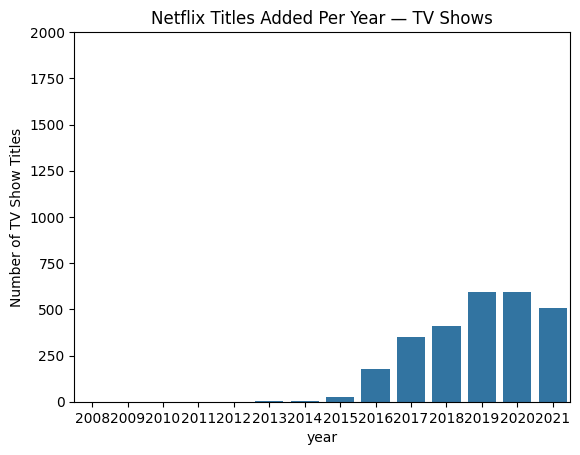

In [336]:
sns.barplot(x = show_per_year.index, y = show_per_year)
plt.ylim(0, 2000)
plt.ylabel("Number of TV Show Titles")
plt.title('Netflix Titles Added Per Year — TV Shows')

In [337]:
movie_per_year = data.groupby('year').movie_duration.count()
movie_per_year

year
2008       1
2009       2
2010       1
2011      13
2012       3
2013       6
2014      19
2015      56
2016     251
2017     836
2018    1237
2019    1424
2020    1284
2021     993
Name: movie_duration, dtype: int64

Text(0.5, 1.0, 'Netflix Titles Added Per Year — Movies')

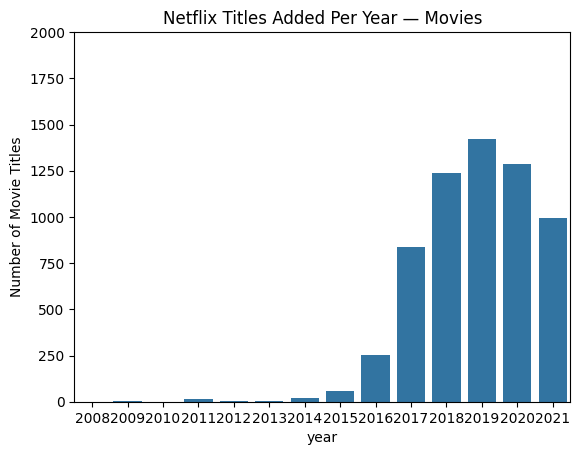

In [338]:
sns.barplot(x = movie_per_year.index, y = movie_per_year)
plt.ylim(0, 2000)
plt.ylabel("Number of Movie Titles")
plt.title('Netflix Titles Added Per Year — Movies')

In [339]:
#Netflix has a catalog that predominantly caters to older people but still has a large amount of content for younger people age 14 and younger.  
rating_dist = data.groupby('rating').show_id.count()
rating_dist.sort_values(ascending=False)

rating
TV-MA       3205
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: show_id, dtype: int64

In [340]:
#International Movies are the the most common genre in the Netflix catalog.
data.listed_in = data.listed_in.str.split(', ')
exploded_data = data.explode('listed_in')
genre_data = exploded_data.groupby('listed_in').show_id.count()
genre_data_sorted = genre_data.sort_values(ascending=False)
genre_data_sorted

listed_in
International Movies            2752
Dramas                          2426
Comedies                        1674
International TV Shows          1349
Documentaries                    869
Action & Adventure               859
TV Dramas                        762
Independent Movies               756
Children & Family Movies         641
Romantic Movies                  616
Thrillers                        577
TV Comedies                      573
Crime TV Shows                   469
Kids' TV                         448
Docuseries                       394
Music & Musicals                 375
Romantic TV Shows                370
Horror Movies                    357
Stand-Up Comedy                  343
Reality TV                       255
British TV Shows                 252
Sci-Fi & Fantasy                 243
Sports Movies                    219
Anime Series                     174
Spanish-Language TV Shows        173
TV Action & Adventure            167
Korean TV Shows             

Netflix clearly went on a spending spree starting around 2016, pumping out over 1,400 movies in 2019 alone as they tried to take over international markets. Most of what's on the platform is movies, not TV shows, though shows have been slowly catching up. If you look at the ratings, almost everything is TV-MA. Netflix is really making content for adults, not families, which makes sense when you think about how they've always tried to feel different from regular TV. After 2019 the numbers drop off, but that's probably just because the dataset ends in 2021 and those last couple years aren't fully captured. The US makes up the biggest chunk of the library by far, but India coming in second is a big deal. Netflix clearly sees a huge opportunity in markets where a growing middle class is getting internet access and disposable income for the first time. South Korea and the UK also punch above their weight, which tracks with Netflix investing in local content to actually feel native to each market rather than just shipping American shows everywhere. The information on genres shows this trend it as well with drama dominating which makes sense because drama travels across cultures in a way that comedy usually doesn't.